In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation

blue_color  = '#348ABD'
red_color   = '#A60628'

In [17]:
avg_opinion = np.load(f"../data/social_impact_avg_opinion.npy")
int_density = np.load(f"../data/social_impact_int_density.npy")
con_matrix  = np.load(f"../data/social_impact_connection_matrix.npy")
opinions    = np.load(f"../data/social_impact_opinions.npy")

Text(0, 0.5, 'Average Opinion')

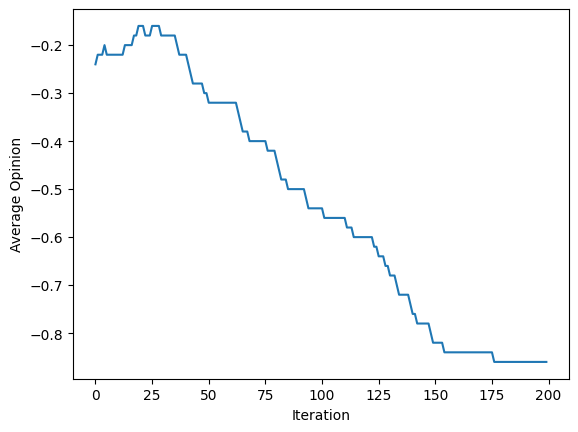

In [18]:
fig = plt.figure()
ax  = fig.add_subplot()
ax.plot(avg_opinion)
ax.set_xlabel("Iteration")
ax.set_ylabel("Average Opinion")

Text(0, 0.5, 'Interface Density')

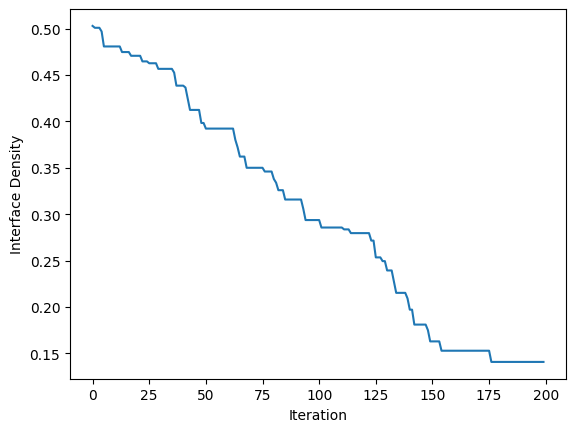

In [19]:
fig = plt.figure()
ax  = fig.add_subplot()
ax.plot(int_density)
ax.set_xlabel("Iteration")
ax.set_ylabel("Interface Density")

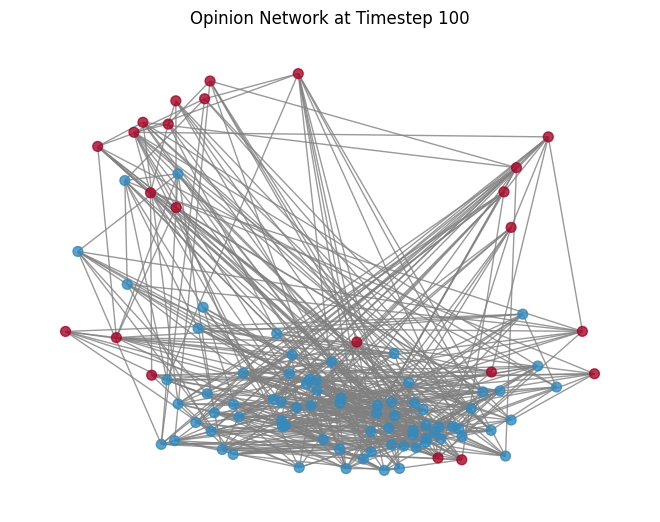

In [20]:
def plot_opinion_graph_at_timestep(opinions, con_matrix, t_step=-1, red_color='#A60628', blue_color='#348ABD', layout_seed=42):
    
    # Construct weighted edges based on opinion alignment
    edges = [
        (i, j, opinions[t_step, i] * opinions[t_step, j])
        for i in range(con_matrix.shape[0])
        for j in range(i+1, con_matrix.shape[0])
        if con_matrix[i, j] != 0
    ]
    
    # Create graph
    G = nx.Graph()
    G.add_weighted_edges_from(edges)

    # Node colors based on opinions
    node_opinions = opinions[t_step, list(G.nodes)]
    node_colors = [red_color if val > 0 else blue_color for val in node_opinions]

    # Layout based on edge weights
    pos = nx.spring_layout(G, seed=layout_seed, weight='weight')

    # Draw the graph
    plt.figure()
    nx.draw(
        G, pos,
        node_color=node_colors,
        edge_color='gray',
        node_size=50,
        alpha=0.8
    )
    plt.title(f"Opinion Network at Timestep {t_step}")
    plt.axis("off")
    plt.show()

t_step  = 100
plot_opinion_graph_at_timestep(opinions, con_matrix, t_step)

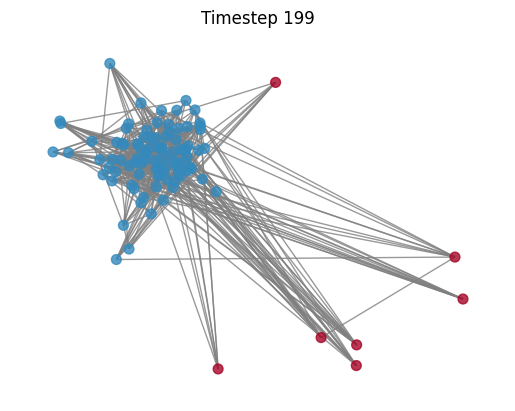

In [21]:
def animate_cluster_forming(opinions, con_matrix, path="opinion_dynamics.gif", blue_color='#348ABD', red_color='#A60628'):
    
    def update(t):
        plt.cla()  # Clear the current axes

        # Update the edges based on opinions at the current timestep
        edges = [
            (i, j, opinions[t, i] * opinions[t, j])
            for i in range(con_matrix.shape[0])
            for j in range(i+1, con_matrix.shape[0])
            if con_matrix[i, j] != 0
        ]

        G = nx.Graph()
        G.add_weighted_edges_from(edges)
        
        # Determine node colors from opinions
        node_opinions   = opinions[t, list(G.nodes)]
        node_colors     = [red_color if val > 0 else blue_color for val in node_opinions]
        
        # Compute layout (cluster movement)
        pos = nx.spring_layout(G, seed=42, weight='weight', iterations=20)  # Based on edge weights

        # Draw graph
        nx.draw(
            G, pos,
            node_color=node_colors,
            edge_color='gray',
            node_size=50,
            alpha=0.8
        )
        
        plt.title(f"Timestep {t}")
        plt.axis("off")

    # Create animation
    fig = plt.figure()
    ani = animation.FuncAnimation(fig, update, frames=len(opinions), interval=100)

    # Save animation as gif
    ani.save(path, writer='pillow')

animate_cluster_forming(opinions, con_matrix)